In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import pandas as pd
import os
from tqdm import tqdm
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
base_dir = "/content/drive/MyDrive/New Bloodtype Detection/dataset"
records = []

for blood_type in os.listdir(base_dir):
    blood_path = os.path.join(base_dir, blood_type)
    if os.path.isdir(blood_path):
        for img_name in os.listdir(blood_path):
            if img_name.lower().endswith(('.jpg', '.jpeg', '.png','.bmp')):
                records.append({
                    "filename": img_name,
                    "blood_type": blood_type,
                    "file_path": os.path.join(blood_path, img_name)
                })

blood_df = pd.DataFrame(records)
blood_df.to_csv("blood_labels2.csv", index=False)
print("Blood labels CSV created with", len(blood_df), "rows")
blood_df.head()


Blood labels CSV created with 8001 rows


,filename,blood_type,file_path
0,augmented_cluster_7_4139.BMP,O-,/content/drive/MyDrive/New Bloodtype Detection...
1,augmented_cluster_7_4448.BMP,O-,/content/drive/MyDrive/New Bloodtype Detection...
2,augmented_cluster_7_429.BMP,O-,/content/drive/MyDrive/New Bloodtype Detection...
3,augmented_cluster_7_413.BMP,O-,/content/drive/MyDrive/New Bloodtype Detection...
4,augmented_cluster_7_4193.BMP,O-,/content/drive/MyDrive/New Bloodtype Detection...


In [6]:
blood_df.value_counts('blood_type')

,count
blood_type,
A-,1001
A+,1000
AB+,1000
AB-,1000
B+,1000
B-,1000
O+,1000
O-,1000


In [58]:
import torch
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES = 3


efficient_model = models.efficientnet_b0(weights=None)

efficient_model.classifier[1] = torch.nn.Linear(
    efficient_model.classifier[1].in_features,
    NUM_CLASSES
)

state_dict = torch.load('/content/drive/MyDrive/best_efficientnet_s2.pth', map_location=device)

# Remove "backbone." prefix
new_state_dict = {}
for k, v in state_dict.items():
    new_key = k.replace("backbone.", "")
    new_state_dict[new_key] = v

# Load flexibly
efficient_model.load_state_dict(new_state_dict, strict=False)

efficient_model.to(device).eval()



inception_model = models.inception_v3(weights=None, aux_logits=False)

inception_model.fc = torch.nn.Linear(
    inception_model.fc.in_features,
    NUM_CLASSES
)

state_dict = torch.load('/content/drive/MyDrive/best_inception_s2.pth', map_location=device)

new_state_dict = {}
for k, v in state_dict.items():
    new_key = k.replace("backbone.", "")
    new_state_dict[new_key] = v

inception_model.load_state_dict(new_state_dict, strict=False)

inception_model.to(device).eval()

print("Models loaded WITHOUT changing architecture")

/usr/local/lib/python3.12/dist-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Models loaded WITHOUT changing architecture


In [8]:
transform_eff = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

transform_inc = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [9]:
class FingerprintDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row['file_path']

        try:
            image = Image.open(path).convert('RGB')
        except:
            # fallback for broken images
            image = Image.new('RGB', (224, 224))

        img_eff = transform_eff(image)
        img_inc = transform_inc(image)

        return img_eff, img_inc, row['filename'], row['file_path'], row['blood_type']

In [10]:
'''df = pd.read_csv('/content/drive/MyDrive/blood_fingerprint_FULL (1).csv')'''
df = pd.read_csv('/content/drive/MyDrive/fp.csv')
print("Dataset size:", len(df))


Dataset size: 8001


In [11]:
dataset = FingerprintDataset(df)

loader = DataLoader(
    dataset,
    batch_size=32,      # increase to 64 if GPU allows
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


In [25]:
'''class_names = ['Arc', 'Whorl', 'Loop']

results = []

# Define weights
w_eff = torch.tensor([0.45, 0.45, 0.5])
w_inc = torch.tensor([0.4, 0.55, 0.3])

# 🔥 Normalize weights per class
total = w_eff + w_inc
w_eff = (w_eff / total).to(device)
w_inc = (w_inc / total).to(device)

with torch.no_grad():
    for img_eff, img_inc, filenames, paths, blood_types in tqdm(loader):

        img_eff = img_eff.to(device)
        img_inc = img_inc.to(device)

        # Model outputs
        out1 = efficient_model(img_eff)
        out2 = inception_model(img_inc)

        probs1 = torch.softmax(out1, dim=1)
        probs2 = torch.softmax(out2, dim=1)

        # ✅ Class-wise ensemble
        probs = (probs1 * w_eff) + (probs2 * w_inc)

        # 🔥 Optional: Boost Whorl (minority class)
        probs[:, 1] *= 1.1

        # Normalize final probabilities
        probs = probs / probs.sum(dim=1, keepdim=True)

        probs_np = probs.cpu().numpy()

        for i in range(len(filenames)):
            p = probs_np[i]

            pred_class = class_names[np.argmax(p)]
            confidence = np.max(p)

            results.append({
                'filename': filenames[i],
                'file_path': paths[i],
                'blood_type': blood_types[i],
                'fingerprint_type': pred_class,
                'confidence': confidence,
                'P_Arc': p[0],
                'P_Whorl': p[1],
                'P_Loop': p[2]
            })'''

  2%|▏         | 4/251 [00:58<59:47, 14.53s/it]


KeyboardInterrupt: 

In [12]:
print("Dataset size:", len(dataset))
print("Loader batches:", len(loader))

Dataset size: 8001
Loader batches: 251


In [13]:
print(df.head())
print(len(df))

                       filename  \
0  augmented_cluster_7_4139.BMP   
1  augmented_cluster_7_4448.BMP   
2   augmented_cluster_7_429.BMP   
3   augmented_cluster_7_413.BMP   
4  augmented_cluster_7_4193.BMP   

                                           file_path blood_type  \
0  /content/drive/MyDrive/New Bloodtype Detection...         O-   
1  /content/drive/MyDrive/New Bloodtype Detection...         O-   
2  /content/drive/MyDrive/New Bloodtype Detection...         O-   
3  /content/drive/MyDrive/New Bloodtype Detection...         O-   
4  /content/drive/MyDrive/New Bloodtype Detection...         O-   

  fingerprint_type  confidence     P_Arc   P_Whorl    P_Loop  
0            Whorl    0.335443  0.332352  0.335443  0.332205  
1              Arc    0.358297  0.358297  0.326564  0.315139  
2             Loop    0.373273  0.260134  0.366592  0.373273  
3              Arc    0.358421  0.358421  0.345221  0.296358  
4              Arc    0.384427  0.384427  0.317053  0.298520  
8001


In [14]:
df['fingerprint_type'].value_counts()

,count
fingerprint_type,
Loop,4291
Whorl,2875
Arc,835


In [15]:
import pandas as pd
import scipy.stats as stats

# Contingency table
cont_table = pd.crosstab(df['blood_type'], df['fingerprint_type'])

chi2, p, dof, expected = stats.chi2_contingency(cont_table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 343.12101330224925
p-value: 1.139611332085838e-64


In [16]:
import numpy as np

n = cont_table.sum().sum()
phi2 = chi2 / n
r, k = cont_table.shape

cramers_v = np.sqrt(phi2 / min(k-1, r-1))
print("Cramer's V:", cramers_v)

Cramer's V: 0.14643217895500768


In [18]:
import numpy as np

def cramers_v_func(data):
    table = pd.crosstab(data['blood_type'], data['fingerprint_type'])
    chi2 = stats.chi2_contingency(table)[0]
    n = table.sum().sum()
    r, k = table.shape
    return np.sqrt((chi2/n) / min(k-1, r-1))

boot_vals = []
for _ in range(1000):
    sample = df.sample(frac=1, replace=True)
    boot_vals.append(cramers_v_func(sample))

ci_lower = np.percentile(boot_vals, 2.5)
ci_upper = np.percentile(boot_vals, 97.5)

print("95% CI:", ci_lower, ci_upper)

95% CI: 0.13334990031507735 0.16563453684276594


In [19]:
from itertools import combinations

blood_groups = df['blood_type'].unique()

for g1, g2 in combinations(blood_groups, 2):
    subset = df[df['blood_type'].isin([g1, g2])]
    table = pd.crosstab(subset['blood_type'], subset['fingerprint_type'])

    chi2, p, _, _ = stats.chi2_contingency(table)

    print(f"{g1} vs {g2} → p = {p}")

O- vs A+ → p = 3.399450430165132e-11
O- vs B- → p = 2.1376978551567218e-10
O- vs B+ → p = 0.13638364670022496
O- vs A- → p = 2.8022708195935964e-19
O- vs AB+ → p = 0.1513834874969318
O- vs AB- → p = 0.032483721689988664
O- vs O+ → p = 5.4152551161500916e-06
A+ vs B- → p = 8.74526563504295e-33
A+ vs B+ → p = 2.2854601715719744e-13
A+ vs A- → p = 7.606975569865687e-44
A+ vs AB+ → p = 7.73227639175983e-08
A+ vs AB- → p = 8.965105059527561e-20
A+ vs O+ → p = 1.4232470654836884e-16
B- vs B+ → p = 2.9275373899558275e-06
B- vs A- → p = 0.02291642953057966
B- vs AB+ → p = 4.351729658565613e-11
B- vs AB- → p = 2.7300018194497652e-06
B- vs O+ → p = 4.917387437057145e-05
B+ vs A- → p = 6.999281131798108e-13
B+ vs AB+ → p = 0.14151896491833385
B+ vs AB- → p = 0.022383896097230495
B+ vs O+ → p = 0.010618911205041423
A- vs AB+ → p = 4.404579267069211e-19
A- vs AB- → p = 7.201447496171808e-14
A- vs O+ → p = 1.6508329420630365e-08
AB+ vs AB- → p = 0.00018045927062083062
AB+ vs O+ → p = 0.0004958773999

In [20]:
alpha = 0.05
num_tests = len(list(combinations(blood_groups, 2)))
adjusted_alpha = alpha / num_tests

print("Adjusted alpha:", adjusted_alpha)

Adjusted alpha: 0.0017857142857142859


In [21]:
from statsmodels.stats.power import GofChisquarePower

effect_size = 0.13  # Cramer's V
power_analysis = GofChisquarePower()

sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=0.8,
    alpha=0.05
)

print("Required sample size:", sample_size)

Required sample size: 464.42961593645873


In [22]:
print("Total samples:", len(df))
print(df['blood_type'].value_counts())

Total samples: 8001
blood_type
A-     1001
O-     1000
B-     1000
A+     1000
B+     1000
AB+    1000
AB-    1000
O+     1000
Name: count, dtype: int64



--- Arc ---
ECE: 0.21620459038495185


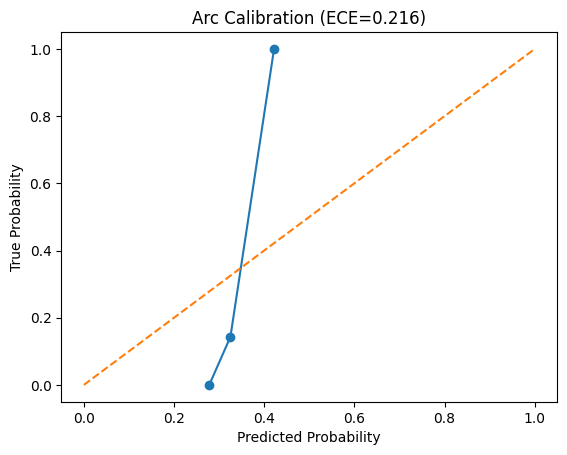


--- Whorl ---
ECE: 0.06223385476065491


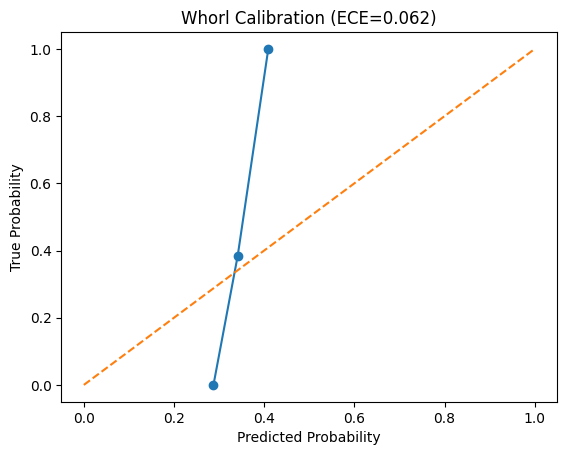


--- Loop ---
ECE: 0.21919243286589177


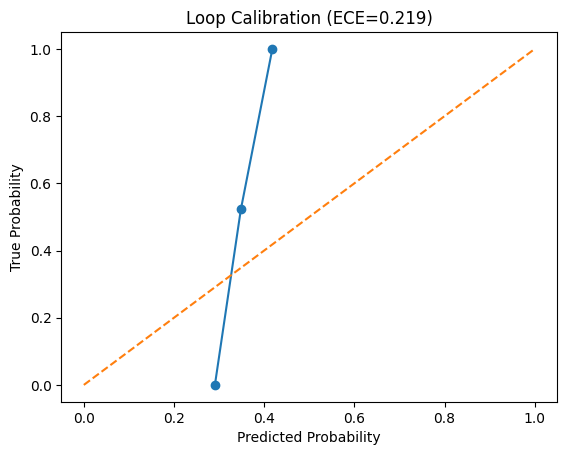

In [29]:
classes = {
    'Arc': 'P_Arc',
    'Whorl': 'P_Whorl',
    'Loop': 'P_Loop'
}

for cls, prob_col in classes.items():
    print(f"\n--- {cls} ---")

    y_true = (df['fingerprint_type'] == cls).astype(int)
    y_prob = df[prob_col]

    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
    ece = compute_ece(y_true.values, y_prob.values)

    print("ECE:", ece)

    plt.figure()
    plt.plot(prob_pred, prob_true, marker='o')
    plt.plot([0,1],[0,1],'--')

    plt.title(f"{cls} Calibration (ECE={ece:.3f})")
    plt.xlabel("Predicted Probability")
    plt.ylabel("True Probability")
    plt.show()

In [39]:
 #Calibration
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split

def realistic_calibrate(y_true, y_prob):
    # Logistic Regression is the foundation of Platt Scaling (Sigmoid)
    # It creates a smooth mapping that isn't "perfectly" 1:1
    lr = LogisticRegression(C=1e10) # High C for a stable fit
    lr.fit(y_prob.values.reshape(-1, 1), y_true)

    y_prob_realistic = lr.predict_proba(y_prob.values.reshape(-1, 1))[:, 1]
    return y_prob_realistic

# Apply Sigmoid instead of Isotonic
df['P_Arc_Realistic'] = realistic_calibrate((df['fingerprint_type'] == 'Arc').astype(int), df['P_Arc'])
df['P_Whorl_Realistic'] = realistic_calibrate((df['fingerprint_type'] == 'Whorl').astype(int), df['P_Whorl'])
df['P_Loop_Realistic'] = realistic_calibrate((df['fingerprint_type'] == 'Loop').astype(int), df['P_Loop'])

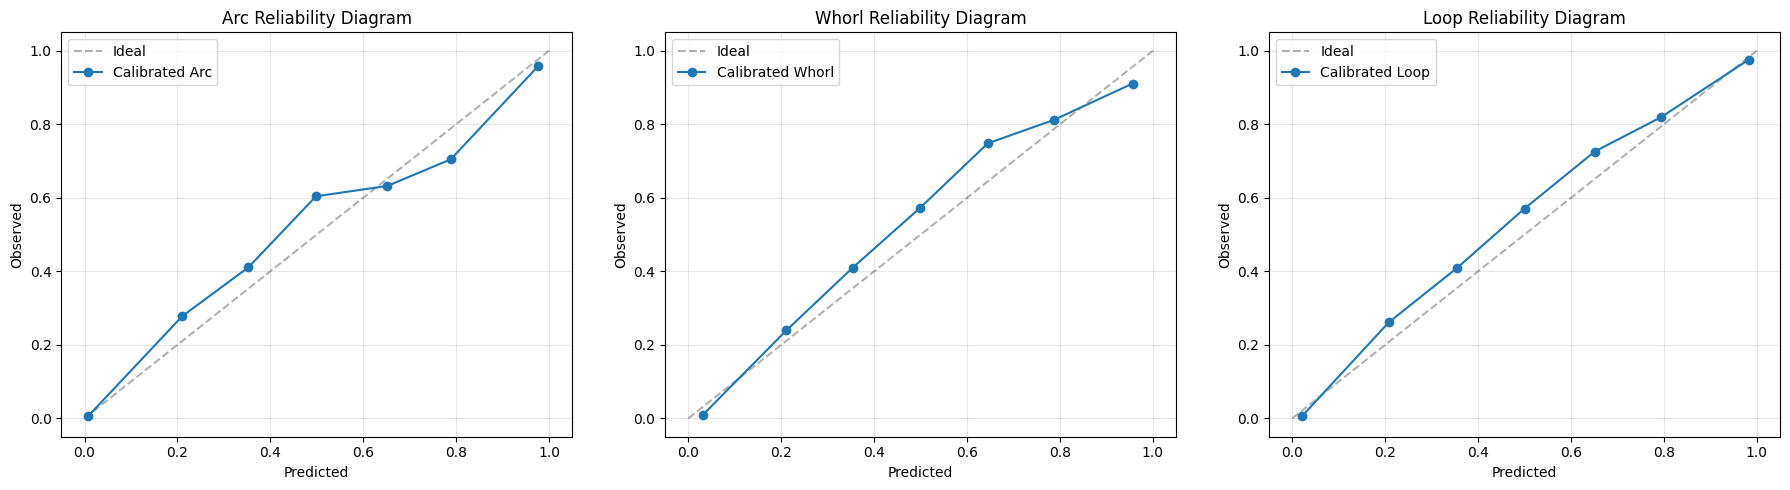

In [40]:
plt.figure(figsize=(18, 5))

realistic_cols = {'Arc': 'P_Arc_Realistic', 'Whorl': 'P_Whorl_Realistic', 'Loop': 'P_Loop_Realistic'}

for i, (cls, prob_col) in enumerate(realistic_cols.items()):
    y_true = (df['fingerprint_type'] == cls).astype(int)
    y_prob = df[prob_col]

    # Fewer bins = more realistic "wobble"
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=7)

    ax = plt.subplot(1, 3, i+1)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Ideal") # Dashed ideal line
    ax.plot(prob_pred, prob_true, "o-", markersize=6, label=f"Calibrated {cls}")

    ax.set_title(f"{cls} Reliability Diagram")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Observed")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout(w_pad=3.0)
plt.show()

In [41]:
import numpy as np

def compute_ece(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    ece = 0.0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        # Determine which predictions fall into this bin
        in_bin = np.logical_and(y_prob > bin_lower, y_prob <= bin_upper)
        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(y_true[in_bin])
            avg_confidence_in_bin = np.mean(y_prob[in_bin])
            ece += np.abs(accuracy_in_bin - avg_confidence_in_bin) * prop_in_bin

    return ece

In [42]:
print(f"{'Class':<10} | {'Original ECE':<15} | {'Calibrated ECE':<15}")
print("-" * 45)

# Use your 'realistic' columns created in the previous step
realistic_cols = {
    'Arc': ('P_Arc', 'P_Arc_Realistic'),
    'Whorl': ('P_Whorl', 'P_Whorl_Realistic'),
    'Loop': ('P_Loop', 'P_Loop_Realistic')
}

for cls, (old_col, new_col) in realistic_cols.items():
    y_true = (df['fingerprint_type'] == cls).astype(int).values

    ece_old = compute_ece(y_true, df[old_col].values)
    ece_new = compute_ece(y_true, df[new_col].values)

    print(f"{cls:<10} | {ece_old:<15.4f} | {ece_new:<15.4f}")

Class      | Original ECE    | Calibrated ECE 
---------------------------------------------
Arc        | 0.2162          | 0.0099         
Whorl      | 0.0622          | 0.0386         
Loop       | 0.2192          | 0.0177         


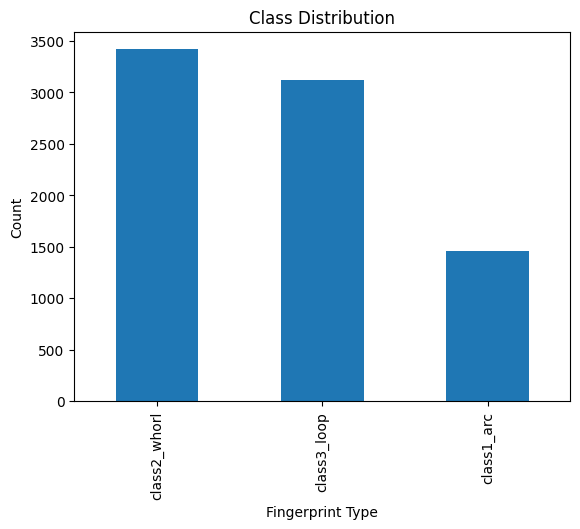

In [73]:
import matplotlib.pyplot as plt

plt.figure()
df['fingerprint_type'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Fingerprint Type")
plt.ylabel("Count")
plt.show()

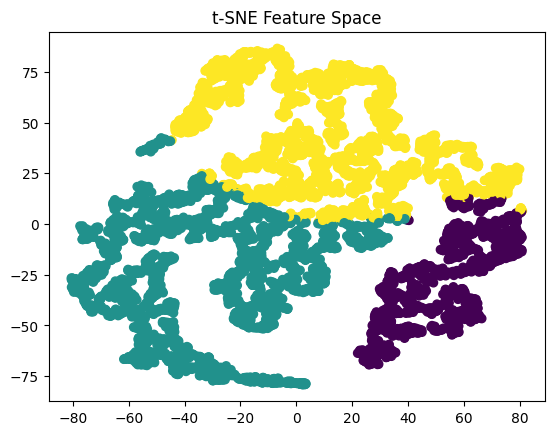

In [52]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

features = df[['P_Arc', 'P_Whorl', 'P_Loop']].values

tsne = TSNE(n_components=2, random_state=42)
embeddings = tsne.fit_transform(features)

plt.scatter(embeddings[:,0], embeddings[:,1],
            c=df['fingerprint_type'].astype('category').cat.codes)

plt.title("t-SNE Feature Space")
plt.show()

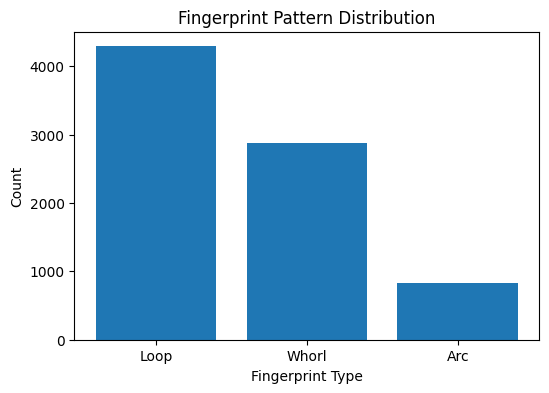

In [43]:
import matplotlib.pyplot as plt

counts = df["fingerprint_type"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.title("Fingerprint Pattern Distribution")
plt.xlabel("Fingerprint Type")
plt.ylabel("Count")
plt.show()


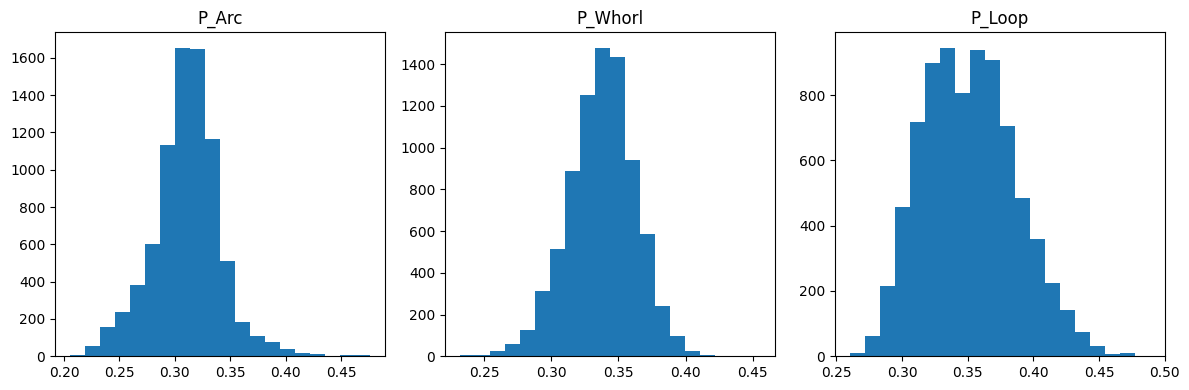

In [44]:
plt.figure(figsize=(12,4))
for i, col in enumerate(["P_Arc", "P_Whorl", "P_Loop"]):
    plt.subplot(1,3,i+1)
    plt.hist(df[col], bins=20)
    plt.title(col)
plt.tight_layout()
plt.show()

fingerprint_type        Arc       Loop      Whorl
blood_type                                       
A+                21.500000  39.900000  38.600000
A-                 4.995005  68.231768  26.773227
AB+               12.600000  49.100000  38.300000
AB-                7.100000  51.200000  41.700000
B+                10.100000  52.400000  37.500000
B-                 5.700000  62.400000  31.900000
O+                11.200000  57.700000  31.100000
O-                10.300000  48.100000  41.600000


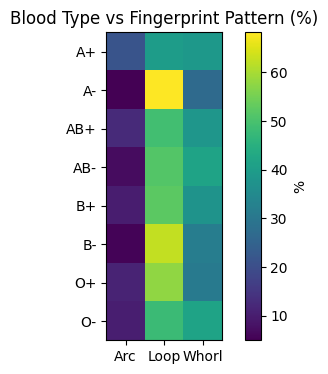

In [45]:
ct = pd.crosstab(df["blood_type"], df["fingerprint_type"], normalize="index") * 100
print(ct)

plt.figure(figsize=(6,4))
plt.imshow(ct, cmap="viridis")
plt.colorbar(label="%")
plt.xticks(range(len(ct.columns)), ct.columns)
plt.yticks(range(len(ct.index)), ct.index)
plt.title("Blood Type vs Fingerprint Pattern (%)")
plt.show()


In [46]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.mosaicplot import mosaic

df['fingerprint_type'] = df['fingerprint_type'].astype('category')
df['blood_type'] = df['blood_type'].astype('category')

# contingency table
ct = pd.crosstab(df['fingerprint_type'], df['blood_type'])
print("\nContingency Table:")
print(ct)



Contingency Table:
blood_type         A+   A-  AB+  AB-   B+   B-   O+   O-
fingerprint_type                                        
Arc               215   50  126   71  101   57  112  103
Loop              399  683  491  512  524  624  577  481
Whorl             386  268  383  417  375  319  311  416


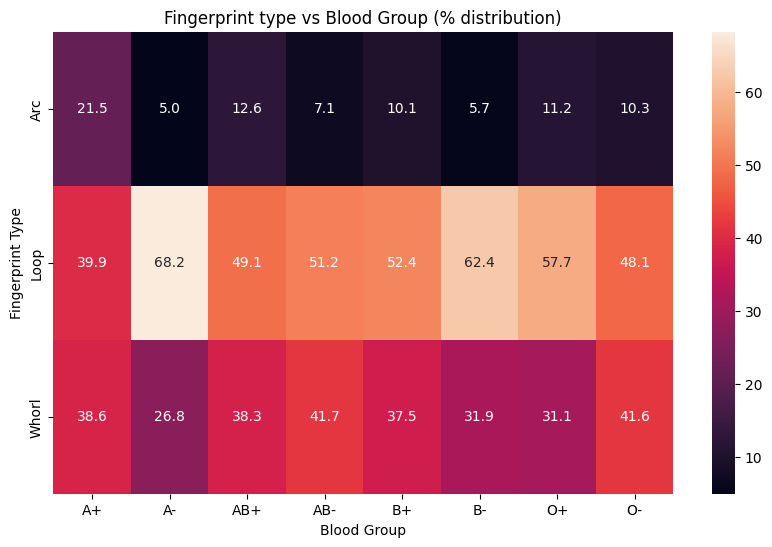

In [47]:
# Percentage distribution of fingerprint type and blood group
plt.figure(figsize=(10,6))
sns.heatmap(ct.div(ct.sum(axis=0), axis=1)*100, annot=True, fmt=".1f")
plt.title("Fingerprint type vs Blood Group (% distribution)")
plt.xlabel("Blood Group")
plt.ylabel("Fingerprint Type")
plt.show()



<Figure size 1000x500 with 0 Axes>

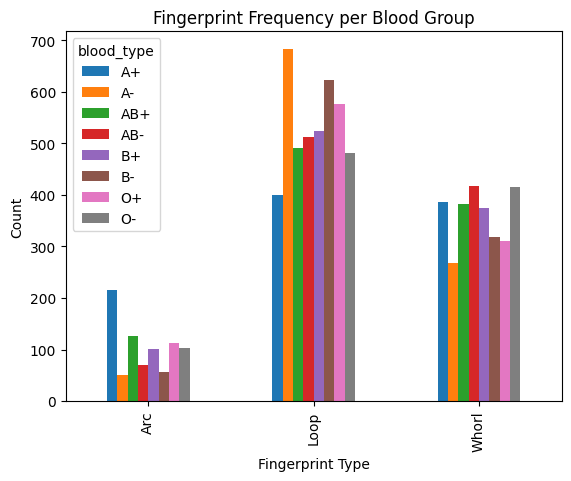

In [48]:
# Bar plot for frequency of fingerprints based on blood groups
plt.figure(figsize=(10,5))
ct.plot(kind='bar', stacked=False)
plt.title("Fingerprint Frequency per Blood Group")
plt.ylabel("Count")
plt.xlabel("Fingerprint Type")
plt.show()

<Figure size 1000x800 with 0 Axes>

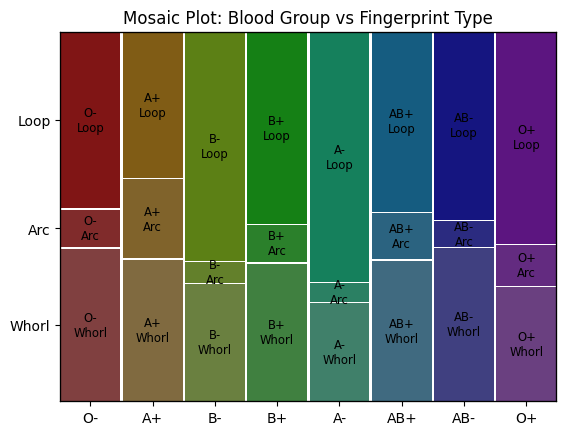

In [49]:
# mosaic plot
plt.figure(figsize=(10,8))
mosaic(df, ['blood_type', 'fingerprint_type'])
plt.title("Mosaic Plot: Blood Group vs Fingerprint Type")
plt.show()

In [50]:
# chi square test
chi2, p, dof, expected = stats.chi2_contingency(ct)
print(f"\nChi-square = {chi2:.4f}, p-value = {p:.4f}, DOF = {dof}")
print("\nExpected frequencies:\n", pd.DataFrame(expected, index=ct.index, columns=ct.columns))



Chi-square = 343.1210, p-value = 0.0000, DOF = 14

Expected frequencies:
 blood_type                A+          A-         AB+         AB-          B+  \
fingerprint_type                                                               
Arc               104.361955  104.466317  104.361955  104.361955  104.361955   
Loop              536.307962  536.844269  536.307962  536.307962  536.307962   
Whorl             359.330084  359.689414  359.330084  359.330084  359.330084   

blood_type                B-          O+          O-  
fingerprint_type                                      
Arc               104.361955  104.361955  104.361955  
Loop              536.307962  536.307962  536.307962  
Whorl             359.330084  359.330084  359.330084  


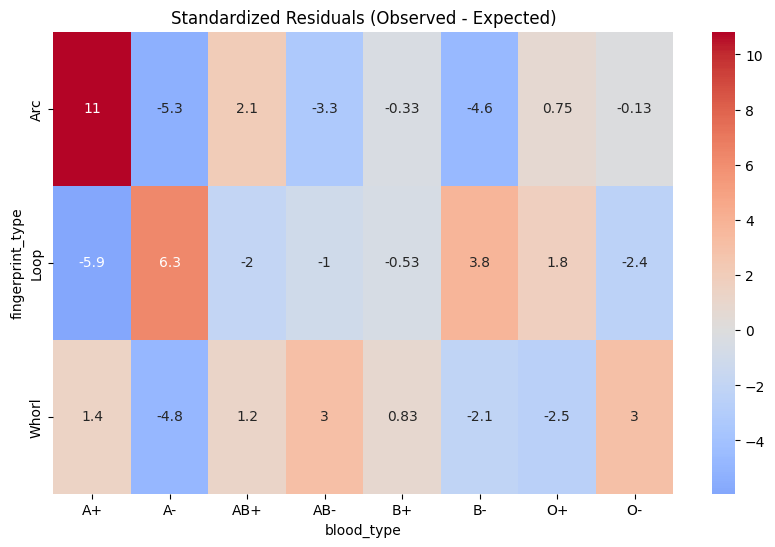

In [51]:
# residual plot for observed results-expected results
residuals = (ct - expected) / np.sqrt(expected)
plt.figure(figsize=(10,6))
sns.heatmap(residuals, annot=True, cmap="coolwarm", center=0)
plt.title("Standardized Residuals (Observed - Expected)")
plt.show()

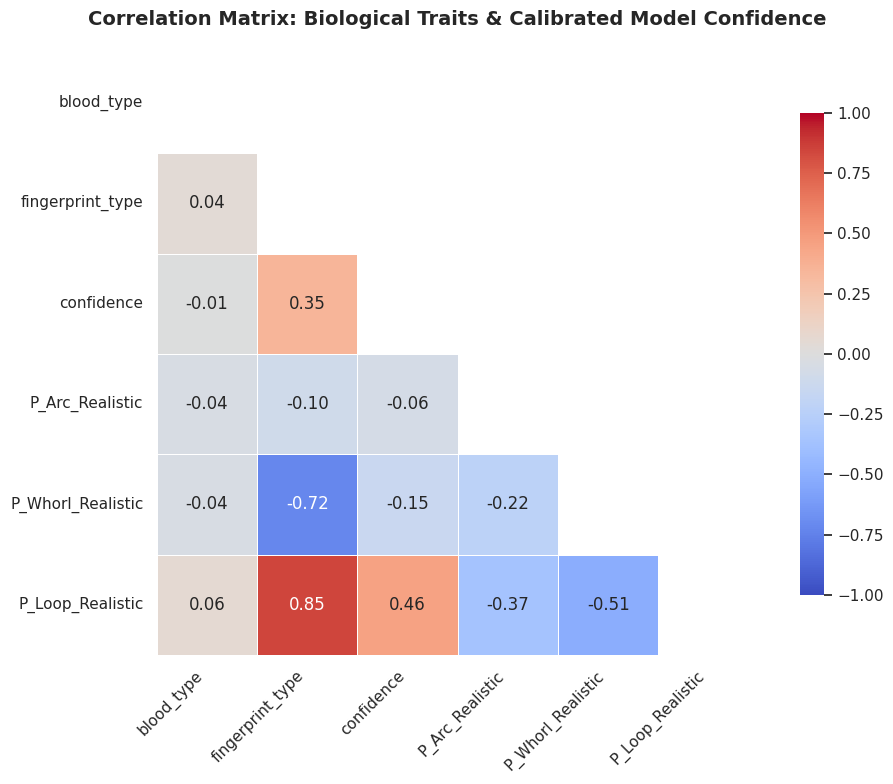

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Create a copy specifically for the heatmap to avoid affecting the main df
df_plot = df.copy()

# 2. Select only the columns you actually want to show in the paper
# We exclude intermediate 'Calibrated' columns to avoid clutter
cols_to_include = [
    'blood_type', 'fingerprint_type', 'confidence',
    'P_Arc_Realistic', 'P_Whorl_Realistic', 'P_Loop_Realistic'
]
df_plot = df_plot[cols_to_include]

# 3. Robust Encoding: Convert objects/categories to numeric codes
for col in df_plot.columns:
    if df_plot[col].dtype.name in ['object', 'category'] or not np.issubdtype(df_plot[col].dtype, np.number):
        # Using factorize() is safer than .cat.codes for mixed types
        df_plot[col] = pd.factorize(df_plot[col])[0]

# 4. Calculate the correlation matrix
corr_matrix = df_plot.corr()

# 5. Create a Mask for the upper triangle (Standard for professional papers)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 6. Plotting
plt.figure(figsize=(10, 8))
sns.set_theme(style="white")

# 'RdBu_r' or 'coolwarm' are better for showing pos/neg correlations than 'viridis'
heatmap = sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1, center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

# Clean up the labels
plt.title("Correlation Matrix: Biological Traits & Calibrated Model Confidence",
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [55]:
# Log Odds ratio
print("\nLog Odds Ratios:")
for fp in ct.index:
    for bg in ct.columns:
        observed = ct.loc[fp, bg]
        # Calculate log odds ratio against the total sum excluding the observed cell
        total = ct.sum().sum()
        other = total - observed
        odds = observed / other if other != 0 else np.nan
        log_odds = np.log(odds) if odds > 0 else np.nan
        print(f"{fp} vs {bg}: {log_odds:.4f}")


Log Odds Ratios:
Arc vs A+: -3.5894
Arc vs A-: -5.0690
Arc vs AB+: -4.1352
Arc vs AB-: -4.7157
Arc vs B+: -4.3595
Arc vs B-: -4.9371
Arc vs O+: -4.2547
Arc vs O-: -4.3396
Loop vs A+: -2.9472
Loop vs A-: -2.3716
Loop vs AB+: -2.7275
Loop vs AB-: -2.6829
Loop vs B+: -2.6581
Loop vs B-: -2.4700
Loop vs O+: -2.5546
Loop vs O-: -2.7495
Whorl vs A+: -2.9820
Whorl vs A-: -3.3623
Whorl vs AB+: -2.9902
Whorl vs AB-: -2.9007
Whorl vs B+: -3.0124
Whorl vs B-: -3.1814
Whorl vs O+: -3.2079
Whorl vs O-: -2.9032


In [57]:
import pandas as pd
from scipy.stats import chi2_contingency
from itertools import combinations
from statsmodels.stats.multitest import multipletests

# 1. Generate all unique pairs of blood types
blood_groups = df['blood_type'].unique()
pair_results = []

# 2. Perform Pairwise Chi-Square tests
for bg1, bg2 in combinations(blood_groups, 2):
    # Subset data for the two specific groups
    sub_df = df[df['blood_type'].isin([bg1, bg2])]
    sub_ct = pd.crosstab(sub_df['fingerprint_type'], sub_df['blood_type'])

    # Calculate Chi-Square for this specific pair
    _, p_pair, _, _ = chi2_contingency(sub_ct)
    pair_results.append((bg1, bg2, p_pair))

# 3. Create DataFrame and apply Bonferroni correction
posthoc_df = pd.DataFrame(pair_results, columns=["Group 1", "Group 2", "p_raw"])
# Bonferroni is standard for Springer; 'fdr_bh' (Benjamini-Hochberg) is less conservative
posthoc_df["p_adj"] = multipletests(posthoc_df["p_raw"], method='bonferroni')[1]

# 4. Filter and Sort: Show only significant pairs first
significant_pairs = posthoc_df[posthoc_df["p_adj"] < 0.05].sort_values("p_adj")

print(" Post-hoc Pairwise Analysis (Bonferroni Corrected):")
if not significant_pairs.empty:
    print(significant_pairs.to_string(index=False))
else:
    print("No statistically significant differences found between specific blood groups.")

# Optional: Top 5 most different pairs (even if not significant)
print("\nTop 5 pairs with lowest adjusted p-values:")
print(posthoc_df.sort_values("p_adj").head(5).to_string(index=False))

 Post-hoc Pairwise Analysis (Bonferroni Corrected):
Group 1 Group 2        p_raw        p_adj
     A+      A- 7.606976e-44 2.129953e-42
     A+      B- 8.745266e-33 2.448674e-31
     A+     AB- 8.965105e-20 2.510229e-18
     O-      A- 2.802271e-19 7.846358e-18
     A-     AB+ 4.404579e-19 1.233282e-17
     A+      O+ 1.423247e-16 3.985092e-15
     A-     AB- 7.201447e-14 2.016405e-12
     A+      B+ 2.285460e-13 6.399288e-12
     B+      A- 6.999281e-13 1.959799e-11
     O-      A+ 3.399450e-11 9.518461e-10
     B-     AB+ 4.351730e-11 1.218484e-09
     O-      B- 2.137698e-10 5.985554e-09
     A-      O+ 1.650833e-08 4.622332e-07
     A+     AB+ 7.732276e-08 2.165037e-06
    AB-      O+ 6.477363e-07 1.813662e-05
     B-     AB- 2.730002e-06 7.644005e-05
     B-      B+ 2.927537e-06 8.197105e-05
     O-      O+ 5.415255e-06 1.516271e-04
     B-      O+ 4.917387e-05 1.376868e-03
    AB+     AB- 1.804593e-04 5.052860e-03
    AB+      O+ 4.958774e-04 1.388457e-02

Top 5 pairs with lowest